In [1]:
import pandas as pd
import numpy as np

In [81]:
df = pd.read_csv("https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv")

In [82]:
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [83]:
num_columns = df.select_dtypes(include=['int64', 'float64']).columns.drop('converted', errors='ignore')
num_columns

Index(['number_of_courses_viewed', 'annual_income', 'interaction_count',
       'lead_score'],
      dtype='str')

In [84]:
categorical_columns = df.select_dtypes(include=['object', 'string']).columns.drop('converted', errors='ignore')
categorical_columns

Index(['lead_source', 'industry', 'employment_status', 'location'], dtype='str')

In [85]:
from sklearn.model_selection import train_test_split

In [86]:
df_fulltrain, df_test = train_test_split(df, test_size = 0.2, random_state = 1)
len(df_fulltrain), len(df_test)

(1169, 293)

In [87]:
df_train, df_val = train_test_split(df_fulltrain, test_size = 0.25, random_state = 1)
len(df_train), len(df_val)

(876, 293)

In [88]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [89]:
y_train = df_train.converted.values
y_test = df_test.converted.values
y_val = df_val.converted.values

In [90]:
df_train = df_train.drop('converted', axis=1)  # use drop() not del
df_val = df_val.drop('converted', axis=1)
df_test = df_test.drop('converted', axis=1)

In [91]:
from sklearn.feature_extraction import DictVectorizer

In [132]:
df_train[categorical_columns] = df_train[categorical_columns].fillna('NA')
df_train[num_columns] = df_train[num_columns].fillna(0)

In [133]:
df_train

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score
0,events,manufacturing,2,95543.0,unemployed,europe,3,0.78
1,referral,NA,1,54924.0,student,south_america,6,0.39
2,organic_search,healthcare,2,77352.0,unemployed,europe,2,0.22
3,paid_ads,other,2,34600.0,employed,south_america,2,0.31
4,paid_ads,education,0,43615.0,unemployed,south_america,2,0.01
...,...,...,...,...,...,...,...,...
871,NA,other,5,67314.0,NA,europe,2,0.87
872,events,education,6,63996.0,NA,australia,4,0.92
873,organic_search,finance,1,73702.0,unemployed,north_america,2,0.55
874,events,technology,1,93341.0,student,middle_east,4,0.99


In [93]:
pd.isna(df_train).sum()

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
dtype: int64

In [94]:
train_dicts = df_train.to_dict(orient = 'records')
train_dicts[:5]

[{'lead_source': 'events',
  'industry': 'manufacturing',
  'number_of_courses_viewed': 2,
  'annual_income': 95543.0,
  'employment_status': 'unemployed',
  'location': 'europe',
  'interaction_count': 3,
  'lead_score': 0.78},
 {'lead_source': 'referral',
  'industry': 'NA',
  'number_of_courses_viewed': 1,
  'annual_income': 54924.0,
  'employment_status': 'student',
  'location': 'south_america',
  'interaction_count': 6,
  'lead_score': 0.39},
 {'lead_source': 'organic_search',
  'industry': 'healthcare',
  'number_of_courses_viewed': 2,
  'annual_income': 77352.0,
  'employment_status': 'unemployed',
  'location': 'europe',
  'interaction_count': 2,
  'lead_score': 0.22},
 {'lead_source': 'paid_ads',
  'industry': 'other',
  'number_of_courses_viewed': 2,
  'annual_income': 34600.0,
  'employment_status': 'employed',
  'location': 'south_america',
  'interaction_count': 2,
  'lead_score': 0.31},
 {'lead_source': 'paid_ads',
  'industry': 'education',
  'number_of_courses_viewed':

In [95]:
dv = DictVectorizer(sparse = False)

In [96]:
X_train = dv.fit_transform(train_dicts)
dv.get_feature_names_out()

array(['annual_income', 'employment_status=NA',
       'employment_status=employed', 'employment_status=self_employed',
       'employment_status=student', 'employment_status=unemployed',
       'industry=NA', 'industry=education', 'industry=finance',
       'industry=healthcare', 'industry=manufacturing', 'industry=other',
       'industry=retail', 'industry=technology', 'interaction_count',
       'lead_score', 'lead_source=NA', 'lead_source=events',
       'lead_source=organic_search', 'lead_source=paid_ads',
       'lead_source=referral', 'lead_source=social_media', 'location=NA',
       'location=africa', 'location=asia', 'location=australia',
       'location=europe', 'location=middle_east',
       'location=north_america', 'location=south_america',
       'number_of_courses_viewed'], dtype=object)

In [97]:
df_val[categorical_columns] = df_val[categorical_columns].fillna('NA')
df_val[num_columns] = df_val[num_columns].fillna(0)

In [98]:
val_dicts = df_val.to_dict(orient = 'records')

In [99]:
X_val = dv.transform(val_dicts)

In [100]:
from sklearn.linear_model import LogisticRegression

In [101]:
model = LogisticRegression(C=1.0, max_iter=1000, random_state=1)

In [102]:

from sklearn.metrics import roc_auc_score, roc_curve

In [103]:
for c in num_columns:
    auc = roc_auc_score(y_train, df_train[c])
    if auc < 0.5:
        auc = roc_auc_score(y_train, -df_train[c])
    print(c, auc)

number_of_courses_viewed 0.7635680590007088
annual_income 0.5519578313253012
interaction_count 0.738270176293409
lead_score 0.6144993577250176


Question 1 answer: number_of_courses_viewed has highest AUC score

In [104]:
model.fit(X_train, y_train)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [105]:
y_pred = model.predict_proba(X_val)[:, 1]
y_pred

array([0.02478614, 0.64996101, 0.89122286, 0.47597624, 0.9397093 ,
       0.87073799, 0.99746255, 0.19731638, 0.36783721, 0.99900859,
       0.96709131, 0.63194854, 0.99949432, 0.12820415, 0.9493801 ,
       0.99327644, 0.50060695, 0.01785415, 0.72600934, 0.977933  ,
       0.94062437, 0.19566631, 0.99678071, 0.40892982, 0.9995674 ,
       0.33469167, 0.04068135, 0.96296004, 0.7280396 , 0.86863089,
       0.65315492, 0.71470112, 0.08089758, 0.99876202, 0.13864186,
       0.93691344, 0.90113449, 0.95006668, 0.01886545, 0.28633118,
       0.98676435, 0.08320506, 0.37021406, 0.68370033, 0.88323943,
       0.07335176, 0.31128293, 0.34675818, 0.7809921 , 0.98459772,
       0.96624695, 0.10681407, 0.99879583, 0.93264523, 0.95365101,
       0.74160727, 0.89537891, 0.28752632, 0.20141581, 0.86865448,
       0.00227175, 0.46544267, 0.03626552, 0.30029797, 0.31173077,
       0.1623125 , 0.92262551, 0.00471673, 0.30493869, 0.84116643,
       0.99470903, 0.64035419, 0.369577  , 0.98696914, 0.61502

In [106]:
model_auc = roc_auc_score(y_val, y_pred)
print(model_auc)

0.919231137954175


Question 2 answer: 0.92

In [107]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [108]:
from sklearn.metrics import precision_recall_curve

In [109]:
thresholds = np.arange(0.0, 1.0, 0.01)
thresholds

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99])

In [110]:
evaluation = []
for t in thresholds:
    y_decision = (y_pred>= t).astype(int)
    evaluation.append([precision_score (y_val, y_decision), recall_score(y_val, y_decision)])
print(evaluation)

[[0.5836177474402731, 1.0], [0.59375, 1.0], [0.6107142857142858, 1.0], [0.6115107913669064, 0.9941520467836257], [0.6181818181818182, 0.9941520467836257], [0.625, 0.9941520467836257], [0.6305970149253731, 0.9883040935672515], [0.6329588014981273, 0.9883040935672515], [0.6377358490566037, 0.9883040935672515], [0.6425855513307985, 0.9883040935672515], [0.6436781609195402, 0.9824561403508771], [0.6461538461538462, 0.9824561403508771], [0.6511627906976745, 0.9824561403508771], [0.65625, 0.9824561403508771], [0.6640316205533597, 0.9824561403508771], [0.6666666666666666, 0.9824561403508771], [0.672, 0.9824561403508771], [0.6761133603238867, 0.9766081871345029], [0.6872427983539094, 0.9766081871345029], [0.6991525423728814, 0.9649122807017544], [0.7112068965517241, 0.9649122807017544], [0.7205240174672489, 0.9649122807017544], [0.7224669603524229, 0.9590643274853801], [0.7224669603524229, 0.9590643274853801], [0.7256637168141593, 0.9590643274853801], [0.7387387387387387, 0.9590643274853801], 

In [111]:
import matplotlib.pyplot as plt

In [112]:
eval_array = np.array(evaluation)
eval_array

array([[0.58361775, 1.        ],
       [0.59375   , 1.        ],
       [0.61071429, 1.        ],
       [0.61151079, 0.99415205],
       [0.61818182, 0.99415205],
       [0.625     , 0.99415205],
       [0.63059701, 0.98830409],
       [0.6329588 , 0.98830409],
       [0.63773585, 0.98830409],
       [0.64258555, 0.98830409],
       [0.64367816, 0.98245614],
       [0.64615385, 0.98245614],
       [0.65116279, 0.98245614],
       [0.65625   , 0.98245614],
       [0.66403162, 0.98245614],
       [0.66666667, 0.98245614],
       [0.672     , 0.98245614],
       [0.67611336, 0.97660819],
       [0.6872428 , 0.97660819],
       [0.69915254, 0.96491228],
       [0.7112069 , 0.96491228],
       [0.72052402, 0.96491228],
       [0.72246696, 0.95906433],
       [0.72246696, 0.95906433],
       [0.72566372, 0.95906433],
       [0.73873874, 0.95906433],
       [0.73873874, 0.95906433],
       [0.73873874, 0.95906433],
       [0.74545455, 0.95906433],
       [0.75115207, 0.95321637],
       [0.

In [113]:
precisions = eval_array[:, 0]
recalls = eval_array[:, 1]

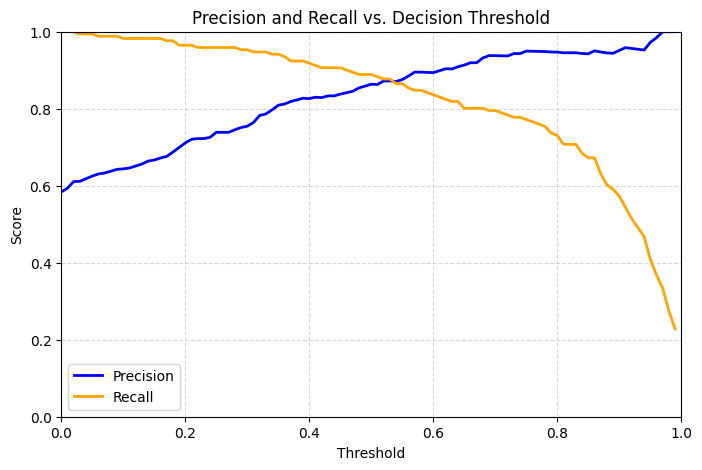

In [114]:
plt.figure(figsize = (8, 5))
plt.plot(thresholds, precisions, label='Precision', color='blue', linewidth=2)
plt.plot(thresholds, recalls, label='Recall', color='orange', linewidth=2)
plt.title('Precision and Recall vs. Decision Threshold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.show()

Question 3 answer is 0.545

In [115]:
f1scores = []
for scores in evaluation:
    f1score = 2 * (scores[0] * scores[1]) / (scores[0] + scores[1])
    f1scores.append(f1score)
f1scores

[0.7370689655172414,
 0.7450980392156863,
 0.7583148558758315,
 0.7572383073496658,
 0.7623318385650224,
 0.7674943566591423,
 0.7699316628701595,
 0.7716894977168949,
 0.7752293577981652,
 0.7788018433179724,
 0.7777777777777777,
 0.7795823665893272,
 0.7832167832167831,
 0.7868852459016393,
 0.7924528301886793,
 0.7943262411347518,
 0.7980997624703088,
 0.799043062200957,
 0.8067632850241546,
 0.8108108108108109,
 0.8188585607940446,
 0.825,
 0.8241206030150753,
 0.8241206030150753,
 0.8261964735516372,
 0.8346055979643766,
 0.8346055979643766,
 0.8346055979643766,
 0.8388746803069054,
 0.8402061855670102,
 0.8423772609819121,
 0.8459530026109661,
 0.8571428571428571,
 0.8594164456233422,
 0.8632707774798929,
 0.8702702702702702,
 0.8695652173913043,
 0.8681318681318682,
 0.8705234159779615,
 0.8729281767955801,
 0.8698060941828255,
 0.8690807799442897,
 0.8659217877094971,
 0.8683473389355743,
 0.8683473389355743,
 0.8707865168539327,
 0.8700564971751413,
 0.8693181818181818,
 0.871

In [116]:
best_threshold, best_f1 = max(zip(thresholds, f1scores), key=lambda x: x[1])
best_threshold, best_f1

(np.float64(0.5), 0.8760806916426512)

Q4: 0.5 - thresh, 0.876 - max

In [117]:
from sklearn.model_selection import KFold

In [118]:
kf = KFold(n_splits=5, shuffle=True, random_state=1)

In [119]:
from sklearn.model_selection import cross_val_score

In [120]:
scores = cross_val_score(model, X_train, y_train, cv=5)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproc

In [121]:
scores

array([0.875     , 0.82857143, 0.81142857, 0.83428571, 0.84571429])

In [122]:
print(np.std(scores)) 
print(np.mean(scores))

0.02112933930798209
0.8390000000000001


Q5 answer is 0.02

In [78]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[columns].to_dict(orient='records')

    dv = DictVectorizer()
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X_train, y_train)

    return dv, model

def predict(df, dv, model):
    dicts = df[columns].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [79]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

for C in [0.000001, 0.001, 1]:
    scores = []

    for train_idx, val_idx in kfold.split(df_fulltrain):
        df_train = df_fulltrain.iloc[train_idx]
        df_val = df_fulltrain.iloc[val_idx]

        df_train[categorical_columns] = df_train[categorical_columns].fillna('NA')
        df_train[num_columns] = df_train[num_columns].fillna(0)
        df_val[categorical_columns] = df_val[categorical_columns].fillna('NA')
        df_val[num_columns] = df_val[num_columns].fillna(0)
        
        y_train = df_train.converted.values
        y_val = df_val.converted.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print('C=%4s, %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

C=1e-06, 0.560 +- 0.024
C=0.001, 0.867 +- 0.029
C=   1, 0.822 +- 0.036
